In [1]:
from typing import Any
from __future__ import annotations

from IPython.display import display, Markdown

import sys
from datetime import datetime, timezone
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import ast
import isodate
import pandas as pd
import numpy as np

ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))

import src.core.util_examplification as examplification
BASE_DIR = Path("../data/raw")

PALETTE: dict[str, str] = {
    "bg": "#0D0F1A",
    "panel": "#141726",
    "accent1": "#FF4D6D",
    "accent2": "#4CC9F0",
    "accent3": "#F4A261",
    "accent4": "#2EC4B6",
    "text": "#E8EAF0",
    "muted": "#6C7293",
}
datasets: dict[str, list[Any]] = {
    "videos": [],
    "comments": [],
    "channels": [],
}
def printf(text_format):
    display(Markdown(text_format))
    
for csv_file in BASE_DIR.rglob("*.csv"):
    try:
        df = pd.read_csv(csv_file)

        df["source_file"] = csv_file.name
        df["source_path"] = str(csv_file)

        id_dir = next(
            (part for part in csv_file.parts if part.startswith("id_")),
            None
        )
        df["collection_id"] = id_dir

        stem_parts = csv_file.stem.split("_")
        country: str = stem_parts[-1] if len(stem_parts) > 2 else None
        df["country"] = country

        filename = csv_file.name.lower()

        if "video" in filename:
            datasets["videos"].append(df)

        elif "comment" in filename:
            datasets["comments"].append(df)

        elif "channel" in filename:
            datasets["channels"].append(df)

    except Exception as e:
        print(f"Erro ao ler {csv_file}: {e}")

videos_df = pd.concat(datasets["videos"], ignore_index=True) \
    if datasets["videos"] else pd.DataFrame()

comments_df = pd.concat(datasets["comments"], ignore_index=True) \
    if datasets["comments"] else pd.DataFrame()

channels_df = pd.concat(datasets["channels"], ignore_index=True) \
    if datasets["channels"] else pd.DataFrame()

print(f"Videos: {len(videos_df)}")
print(f"Comments: {len(comments_df)}")
print(f"Channels: {len(channels_df)}")


Videos: 1129
Comments: 48450
Channels: 1129


In [2]:

printf("# visão geral e estrutura do dataset")
printf("## amostra dos dados (primeiras 5 linhas)")
display(videos_df.head())

display(Markdown("---"))

printf("##  rsumo estatístico (variáveis nméricas)")
display(videos_df.describe()) 

if videos_df.select_dtypes(include=['object']).shape[1] > 0:
    printf("## resumo estatístico (variáveis categóricas)")
    display(videos_df.describe())

# visão geral e estrutura do dataset

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_title,channel_id,published_at,category_id,thumbnail,view_count,like_count,comment_count,tags,duration,source_file,source_path,collection_id,country
0,Au1UwwOX6JU,EU ZEREI HELLO NEIGHBOUR... MAS COM UMA DOZE!,Jazzghost,UCIXguhHCl8eDTkXpEuiGPUA,2026-06-02T15:27:08Z,20,https://i.ytimg.com/vi/Au1UwwOX6JU/default.jpg,256490,28386.0,2317.0,"['jazzghost', 'jazz', 'hello neighbour']",PT40M1S,youtube_videos_br.csv,../data/raw/output_160902062026/id_20/youtube_...,id_20,br
1,B9az2JVfDbE,Evolui Minha PICARETA no NÍVEL MÁXIMO no Minec...,ProbIems,UCrcBZDofBltcgGxphNia2tw,2026-06-02T13:00:14Z,20,https://i.ytimg.com/vi/B9az2JVfDbE/default.jpg,155209,5770.0,393.0,"['maniqueft', 'lego', 'problems', 'probrems', ...",PT16M29S,youtube_videos_br.csv,../data/raw/output_160902062026/id_20/youtube_...,id_20,br
2,vmqvPlJvpj4,PASSANDO A PERNA NOS MEUS AMIGOS EM UM LEILÃO!...,alanzoka,UCIwspRtKNszHhIhl36gREjQ,2026-06-02T15:00:11Z,20,https://i.ytimg.com/vi/vmqvPlJvpj4/default.jpg,75104,13575.0,222.0,"['alan', 'electronic', 'desire', 'edge', 'alan...",PT1H18M40S,youtube_videos_br.csv,../data/raw/output_160902062026/id_20/youtube_...,id_20,br
3,j6zdTivY0mI,Henrique e Juliano 2026 Letra - As Mais Tocada...,Grow Stest,UC0Ohlg-zWxV1MdTA5IqCTMg,2026-06-01T13:58:34Z,10,https://i.ytimg.com/vi/j6zdTivY0mI/default_liv...,45746,368.0,14.0,"['Henrique e Juliano', 'Mais Tocadas', 'Henriq...",PT1H3M6S,youtube_videos_br.csv,../data/raw/output_160902062026/id_20/youtube_...,id_20,br
4,R2u139fASRw,SALLY FACE E O MISTÉRIO DA MORTADELA - Capítulo 3,Felipe Neto Joga,UCIzdh7oty8jCnXUj3eUj2WQ,2026-06-01T15:00:03Z,24,https://i.ytimg.com/vi/R2u139fASRw/default.jpg,376423,50854.0,2630.0,[],PT1H31M8S,youtube_videos_br.csv,../data/raw/output_160902062026/id_20/youtube_...,id_20,br


---

##  rsumo estatístico (variáveis nméricas)

,category_id,view_count,like_count,comment_count
count,1129.000000,1.129000e+03,1.095000e+03,1128.000000
mean,21.455270,2.373519e+06,6.807891e+04,555.730496
std,3.886692,8.257624e+06,1.611152e+05,1494.007587
min,1.000000,1.044700e+04,1.170000e+02,0.000000
25%,20.000000,1.307930e+05,6.397500e+03,72.000000
50%,22.000000,6.069290e+05,2.411700e+04,195.500000
75%,24.000000,1.554082e+06,6.927400e+04,523.250000
max,29.000000,1.584960e+08,2.664481e+06,23326.000000


/tmp/ipykernel_45919/886918004.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if videos_df.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count
count,1129.000000,1.129000e+03,1.095000e+03,1128.000000
mean,21.455270,2.373519e+06,6.807891e+04,555.730496
std,3.886692,8.257624e+06,1.611152e+05,1494.007587
min,1.000000,1.044700e+04,1.170000e+02,0.000000
25%,20.000000,1.307930e+05,6.397500e+03,72.000000
50%,22.000000,6.069290e+05,2.411700e+04,195.500000
75%,24.000000,1.554082e+06,6.927400e+04,523.250000
max,29.000000,1.584960e+08,2.664481e+06,23326.000000


In [3]:

printf(f"Videos: {len(videos_df)}")
df: pd.DataFrame = videos_df.drop_duplicates(subset=["video_id"])
printf(f"Videos: {len(df)}")

Videos: 1129

Videos: 711

In [4]:
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")

for col in ["view_count", "like_count", "comment_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["video_id", "title", "channel_title", "channel_id", "thumbnail",
            "tags", "duration", "source_file", "source_path", "collection_id", "country"]:
    df[col] = df[col].astype("string").str.strip()

In [5]:
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    return int(isodate.parse_duration(x).total_seconds())

df["duration_seconds"] = df["duration"].apply(duration_to_seconds)
df["is_short"] = df["duration_seconds"] <= 60

In [6]:
def parse_tags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return [t.strip().lower() for t in ast.literal_eval(x)]
    except:
        return [t.strip().lower() for t in str(x).strip("[]").split(",") if t.strip()]

df["tags_list"] = df["tags"].apply(parse_tags)
df["tags_n"] = df["tags_list"].apply(len)

In [7]:
# df["like_count_missing"] = df["like_count"].isna().astype(int)
# df["comment_count_missing"] = df["comment_count"].isna().astype(int)
df["title_len"] = df["title"].str.len()
df["title_words"] = df["title"].str.split().apply(len)

df["log_view_count"] = np.log1p(df["view_count"])
df["log_like_count"] = np.log1p(df["like_count"])
df["log_comment_count"] = np.log1p(df["comment_count"])

df["engagement_rate"] = (df["like_count"] + df["comment_count"]) / df["view_count"]
df["likes_per_view"] = df["like_count"] / df["view_count"]
df["comments_per_view"] = df["comment_count"] / df["view_count"]

,title,country,view_count,published_at,duration_seconds
210,Camisa De Tinta,br,158453716,2026-05-22 00:15:10+00:00,56
253,Porque você vive cansada sendo que vc dormi mu...,br,53012326,2026-05-25 02:37:20+00:00,25
770,Ranking The Best How Did They Do That? Moments,br,45232886,2026-05-22 14:03:35+00:00,39
957,My mom helped me 😯 #funny #Sigma,br,38314251,2026-05-07 12:01:53+00:00,34
689,This Trick Shot Almost Made Him QUIT,br,37268831,2026-05-25 18:55:41+00:00,66
244,Allah tala ki madad #shortsfeed #shorts #newso...,br,33100180,2026-05-29 20:30:46+00:00,14
901,Bala funny short 🤓😳😜#shorts #tranding #funny #...,br,32288964,2026-05-17 09:10:33+00:00,12
140,Ronaldo ❤️,br,31115056,2026-05-24 22:52:52+00:00,59
940,Trying to buy stuff not for sale #funny #fyp #...,br,29630724,2026-05-13 11:41:32+00:00,45
321,jbl go4 pvc pipe drop jumping,br,28858026,2026-05-26 02:56:05+00:00,26


---

### Problema encontrado... os videos curtos, ou 'shorts' são máquinas de outliers, e säo extremamente pobres em engajamento

### Sua natureza pode quebrar a precisão do estudo

### Total de videos: 711

...

### Total de shorts: 353

---

Se definirmos:
- L = número de likes
- C = número de comentários
- V = número de visualizações

(5*C + 2*L)/V

,title,country,view_count,published_at,duration_seconds
99,JOGO COMPLETO: BRASIL X PANAMÁ | AMISTOSO INTE...,br,24863248,2026-06-01 01:32:45+00:00,20108
100,PSG VENCE O ARSENAL NOS PÊNALTIS E É O CAMPEÃO...,br,9400812,2026-05-30 20:34:49+00:00,23671
965,A LEIA FURACÃO SAIU DA PRISÃO *Ela visitou a m...,br,3677467,2026-05-23 21:00:04+00:00,981
1110,"The Truth About the ""Whoop Killer""",br,3379793,2026-05-26 13:49:28+00:00,1062
554,MR BABY👶 vs CRY BABY😱👶🔥WWE 2K25 SHORTS LIVE 🔴#...,br,3078638,2026-05-31 18:13:50+00:00,18321
745,🔴 PSG X ARSENAL | AO VIVO AGORA | FINAL CHAMPI...,br,2266215,2026-05-30 19:31:57+00:00,22102
562,i hosted ADMIN ABUSE..,br,2209930,2026-05-30 20:11:14+00:00,5965
693,BRASIL X PANAMÁ JOGO AO VIVO - DIRETO DO ESTÁD...,br,2009946,2026-06-01 00:41:07+00:00,22924
558,Trolleando con Bases Secretas a Mis Amigos en ...,br,1651956,2026-05-30 19:59:15+00:00,1466
555,『 NO NO NO GRANNY!! 』☠️ Don’t Catch Me!! 🏃‍♂️|...,br,1530459,2026-05-31 19:58:35+00:00,5504


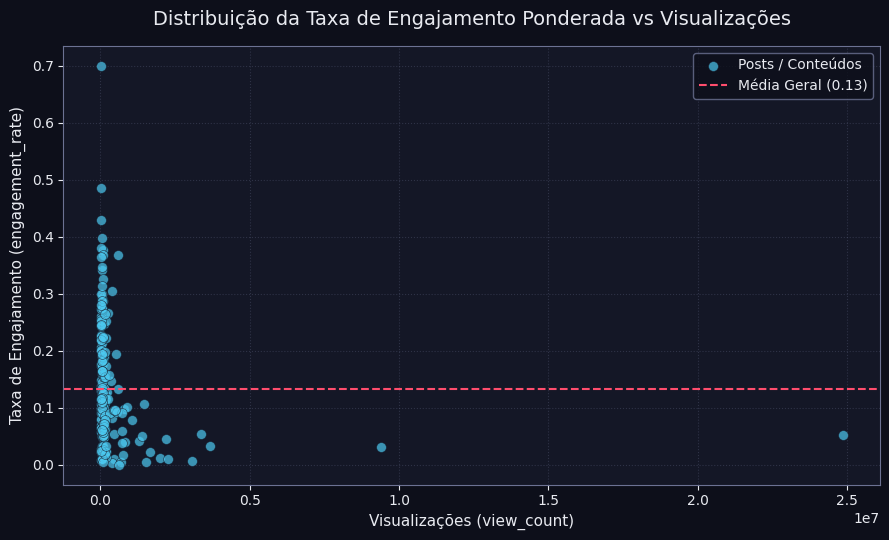

In [8]:
LIKE_WEIGHT = 2
COMMENT_WEIGHT = 5
display(df.nlargest(10, "view_count")[
    ["title", "country", "view_count", "published_at","duration_seconds"]
])
printf("---")
printf("### Problema encontrado... os videos curtos, ou 'shorts' são máquinas de outliers, e säo extremamente pobres em engajamento")
printf("### Sua natureza pode quebrar a precisão do estudo")

shorts = df[df["duration_seconds"] < 60]
printf(f"### Total de videos: {len(df)}")
printf(f"### Total de videos não shorts {len(df)-len(shorts)}")
printf(f"### Total de shorts: {len(shorts)}")
printf("---")

df_long = df[df["duration_seconds"] >= 240]

df_long["engagement_rate"] = np.where(
    df_long["view_count"].gt(0),
    (
        df_long["like_count"]* LIKE_WEIGHT +
        df_long["comment_count"]* COMMENT_WEIGHT
    ) / df_long["view_count"],
    np.nan
)
examplification.plot_engagement_rate_example(df_long, LIKE_WEIGHT, COMMENT_WEIGHT)
df_long["likes_per_view"] = np.where(
    df_long["view_count"] > 0,
    df_long["like_count"] / df_long["view_count"],
    np.nan
)

df_long["comments_per_view"] = np.where(
    df_long["view_count"] > 0,
    df_long["comment_count"] / df_long["view_count"],
    np.nan
)
display(df_long.nlargest(10, "view_count")[
    ["title", "country", "view_count", "published_at","duration_seconds"]
])

Se definirmos:
- L = número de likes
- C = número de comentários
- V = número de visualizações

(5*C + 2*L)/V

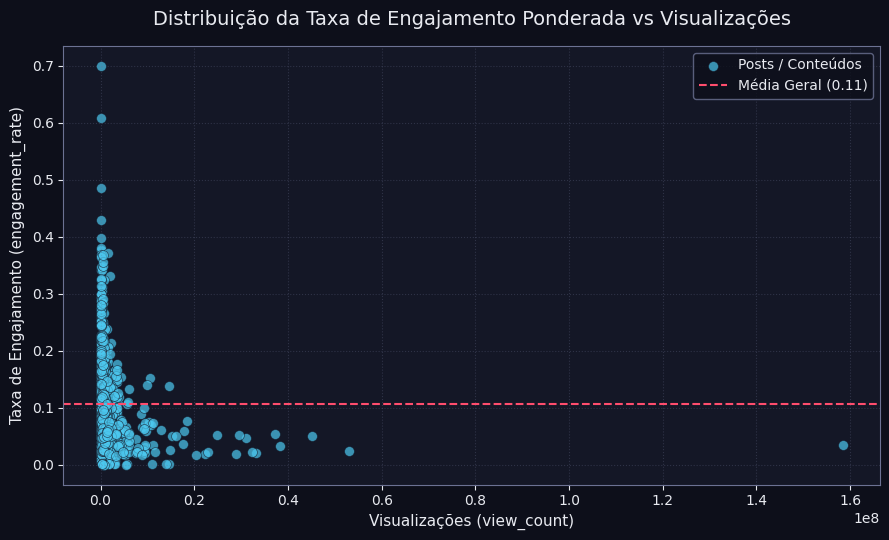

In [9]:
# métricas de engajamento, dá para ter um indicadores de sucesso com
# essas métricas, pois utiliza como critério para ter um comentário ou like é necessário ter tido ao menos uma view
# e engajar significa levar outro individuo a tomar uma acão, logo a view seria a base para os demais, näo há os
# demais sem visualizacão

# df["engagement_rate"] = np.where(
#     df["view_count"] > 0,
#     (df["like_count"] + df["comment_count"]) / df["view_count"],
#     np.nan
# )


# cria uma métrica personalizada chamada taxa de engajamento, dando 
# pesos diferentes para curtidas e comentários.
df["engagement_rate"] = np.where(
    df["view_count"].gt(0),
    (
        df["like_count"]* LIKE_WEIGHT +
        df["comment_count"]* COMMENT_WEIGHT
    ) / df["view_count"],
    np.nan
)
examplification.plot_engagement_rate_example(df, LIKE_WEIGHT, COMMENT_WEIGHT)
df["likes_per_view"] = np.where(
    df["view_count"] > 0,
    df["like_count"] / df["view_count"],
    np.nan
)

df["comments_per_view"] = np.where(
    df["view_count"] > 0,
    df["comment_count"] / df["view_count"],
    np.nan
)

<h3>
       Em dados de redes sociais e YouTube, as distribuições costumam ser extremamente assimétricas.
       O maior valor domina completamente a escala. Criando uma discrepancia enorme na comparacao
       Principalmente neste cenário onde 
       </h3>
       

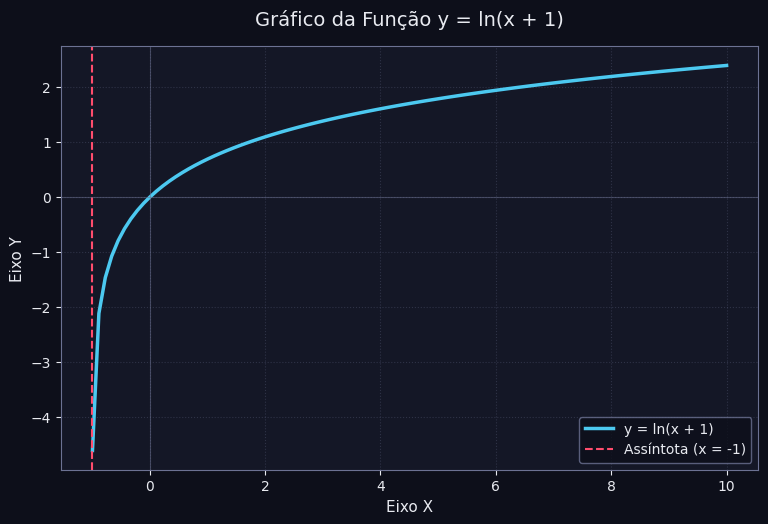

In [10]:

printf(f"""<h3>
       Em dados de redes sociais e YouTube, as distribuições costumam ser extremamente assimétricas.
       O maior valor domina completamente a escala. Criando uma discrepancia enorme na comparacao
       Principalmente neste cenário onde 
       </h3>
       """
       )
examplification.plot_logn1_example()

df["log_view_count"] = np.log1p(df["view_count"])
df["log_like_count"] = np.log1p(df["like_count"])
df["log_comment_count"] = np.log1p(df["comment_count"])
df["log_duration_seconds"] = np.log1p(df["duration_seconds"])



In [11]:
# modelos não entendem data da mesma forma que nos, a grande maioria.
df["published_date"] = df["published_at"].dt.date
df["published_year"] = df["published_at"].dt.year
df["published_month"] = df["published_at"].dt.month
df["published_hour"] = df["published_at"].dt.hour
df["published_dayofweek"] = df["published_at"].dt.day_name()

# posso talvez aplicar algum coisa de carga cognitiva, tendo em mente
# que é um oversimplification das abstracoes para simples números...
df["title_len"] = df["title"].fillna("").str.len()
df["title_words"] = df["title"].fillna("").str.split().apply(len)

USELESS_FIELDS: list[str] = [
    "thumbnail",
    "source_file",
    "source_path",
    "collection_id",
    "tags",
    "duration"
    "published_at"
]
cols_to_drop = [c for c in USELESS_FIELDS if c in df.columns]
df = df.drop(columns=cols_to_drop)


In [12]:

printf("# visão geral e estrutura do dataset")
printf("## amostra dos dados (primeiras 5 linhas)")
display(df.head())

display(Markdown("---"))

printf("##  rsumo estatístico (variáveis nméricas)")
display(df.describe()) 

if df.select_dtypes(include=['object']).shape[1] > 0:
    printf("## resumo estatístico (variáveis categóricas)")
    display(df.describe())

# visão geral e estrutura do dataset

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_title,channel_id,published_at,category_id,view_count,like_count,comment_count,duration,...,log_comment_count,engagement_rate,likes_per_view,comments_per_view,log_duration_seconds,published_date,published_year,published_month,published_hour,published_dayofweek
0,Au1UwwOX6JU,EU ZEREI HELLO NEIGHBOUR... MAS COM UMA DOZE!,Jazzghost,UCIXguhHCl8eDTkXpEuiGPUA,2026-06-02 15:27:08+00:00,20,256490,28386.0,2317.0,PT40M1S,...,7.748460,0.266509,0.110671,0.009033,7.784057,2026-06-02,2026,6,15,Tuesday
1,B9az2JVfDbE,Evolui Minha PICARETA no NÍVEL MÁXIMO no Minec...,ProbIems,UCrcBZDofBltcgGxphNia2tw,2026-06-02 13:00:14+00:00,20,155209,5770.0,393.0,PT16M29S,...,5.976351,0.087012,0.037176,0.002532,6.897705,2026-06-02,2026,6,13,Tuesday
2,vmqvPlJvpj4,PASSANDO A PERNA NOS MEUS AMIGOS EM UM LEILÃO!...,alanzoka,UCIwspRtKNszHhIhl36gREjQ,2026-06-02 15:00:11+00:00,20,75104,13575.0,222.0,PT1H18M40S,...,5.407172,0.376278,0.180749,0.002956,8.459776,2026-06-02,2026,6,15,Tuesday
3,j6zdTivY0mI,Henrique e Juliano 2026 Letra - As Mais Tocada...,Grow Stest,UC0Ohlg-zWxV1MdTA5IqCTMg,2026-06-01 13:58:34+00:00,10,45746,368.0,14.0,PT1H3M6S,...,2.708050,0.017619,0.008044,0.000306,8.239329,2026-06-01,2026,6,13,Monday
4,R2u139fASRw,SALLY FACE E O MISTÉRIO DA MORTADELA - Capítulo 3,Felipe Neto Joga,UCIzdh7oty8jCnXUj3eUj2WQ,2026-06-01 15:00:03+00:00,24,376423,50854.0,2630.0,PT1H31M8S,...,7.875119,0.305130,0.135098,0.006987,8.606851,2026-06-01,2026,6,15,Monday


---

##  rsumo estatístico (variáveis nméricas)

,category_id,view_count,like_count,comment_count,duration_seconds,tags_n,title_len,title_words,log_view_count,log_like_count,log_comment_count,engagement_rate,likes_per_view,comments_per_view,log_duration_seconds,published_year,published_month,published_hour
count,711.000000,7.110000e+02,6.870000e+02,710.000000,711.000000,711.000000,711.0,711.000000,711.000000,687.000000,710.000000,711.000000,687.000000,710.000000,711.000000,711.0,711.000000,711.000000
mean,21.390999,2.322541e+06,6.743939e+04,573.923944,1091.468354,5.648383,52.459916,8.887482,13.227310,9.965763,5.185698,0.105922,0.051387,0.001325,4.759462,2026.0,5.233474,15.654008
std,3.951698,7.732588e+06,1.564513e+05,1551.209126,3637.160399,9.995076,22.545872,3.754246,1.700700,1.620426,1.636943,0.084777,0.038366,0.002472,1.932629,0.0,0.423339,6.387365
min,1.000000,1.044700e+04,1.170000e+02,0.000000,10.000000,0.000000,5.0,1.000000,9.254166,4.770685,0.000000,0.000000,0.001403,0.000000,2.397895,2026.0,5.000000,0.000000
25%,20.000000,1.585310e+05,6.996000e+03,70.250000,25.000000,0.000000,35.0,6.000000,11.973688,8.853234,4.266176,0.049283,0.024641,0.000089,3.258097,2026.0,5.000000,13.000000
50%,22.000000,6.305040e+05,2.463100e+04,193.500000,60.000000,0.000000,49.0,8.000000,13.354276,10.111802,5.270429,0.084982,0.041289,0.000324,4.110874,2026.0,5.000000,17.000000
75%,24.000000,1.553605e+06,6.748000e+04,557.750000,774.000000,7.000000,67.0,11.000000,14.256087,11.119595,6.325702,0.138332,0.067825,0.001382,6.652862,2026.0,5.000000,21.000000
max,29.000000,1.584537e+08,2.663791e+06,23305.000000,42900.000000,55.000000,100.0,23.000000,18.880973,14.795261,10.056466,0.700105,0.318502,0.022642,10.666650,2026.0,6.000000,23.000000


/tmp/ipykernel_45919/915114239.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if df.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count,duration_seconds,tags_n,title_len,title_words,log_view_count,log_like_count,log_comment_count,engagement_rate,likes_per_view,comments_per_view,log_duration_seconds,published_year,published_month,published_hour
count,711.000000,7.110000e+02,6.870000e+02,710.000000,711.000000,711.000000,711.0,711.000000,711.000000,687.000000,710.000000,711.000000,687.000000,710.000000,711.000000,711.0,711.000000,711.000000
mean,21.390999,2.322541e+06,6.743939e+04,573.923944,1091.468354,5.648383,52.459916,8.887482,13.227310,9.965763,5.185698,0.105922,0.051387,0.001325,4.759462,2026.0,5.233474,15.654008
std,3.951698,7.732588e+06,1.564513e+05,1551.209126,3637.160399,9.995076,22.545872,3.754246,1.700700,1.620426,1.636943,0.084777,0.038366,0.002472,1.932629,0.0,0.423339,6.387365
min,1.000000,1.044700e+04,1.170000e+02,0.000000,10.000000,0.000000,5.0,1.000000,9.254166,4.770685,0.000000,0.000000,0.001403,0.000000,2.397895,2026.0,5.000000,0.000000
25%,20.000000,1.585310e+05,6.996000e+03,70.250000,25.000000,0.000000,35.0,6.000000,11.973688,8.853234,4.266176,0.049283,0.024641,0.000089,3.258097,2026.0,5.000000,13.000000
50%,22.000000,6.305040e+05,2.463100e+04,193.500000,60.000000,0.000000,49.0,8.000000,13.354276,10.111802,5.270429,0.084982,0.041289,0.000324,4.110874,2026.0,5.000000,17.000000
75%,24.000000,1.553605e+06,6.748000e+04,557.750000,774.000000,7.000000,67.0,11.000000,14.256087,11.119595,6.325702,0.138332,0.067825,0.001382,6.652862,2026.0,5.000000,21.000000
max,29.000000,1.584537e+08,2.663791e+06,23305.000000,42900.000000,55.000000,100.0,23.000000,18.880973,14.795261,10.056466,0.700105,0.318502,0.022642,10.666650,2026.0,6.000000,23.000000


In [13]:
# display(Markdown(f"\nshape final: {df.shape[0]} linhas x {df.shape[1]} colunas"))

# POS_BASE_DIR = Path("../data/processed")
# POS_BASE_DIR.mkdir(parents=True, exist_ok=True)

# timestamp: str = datetime.now().strftime("%Y%m%d_%H%M%S")
# file_name: str = f"processed_videos_{timestamp}.csv"
# caminho_final: Path = POS_BASE_DIR / file_name

# df.to_csv(caminho_final, index=False, sep=',', encoding='utf-8')

# display(Markdown(f"\nsalvo no caminho: {caminho_final}"))

Salvo em: plots_output/1_boxplots.png


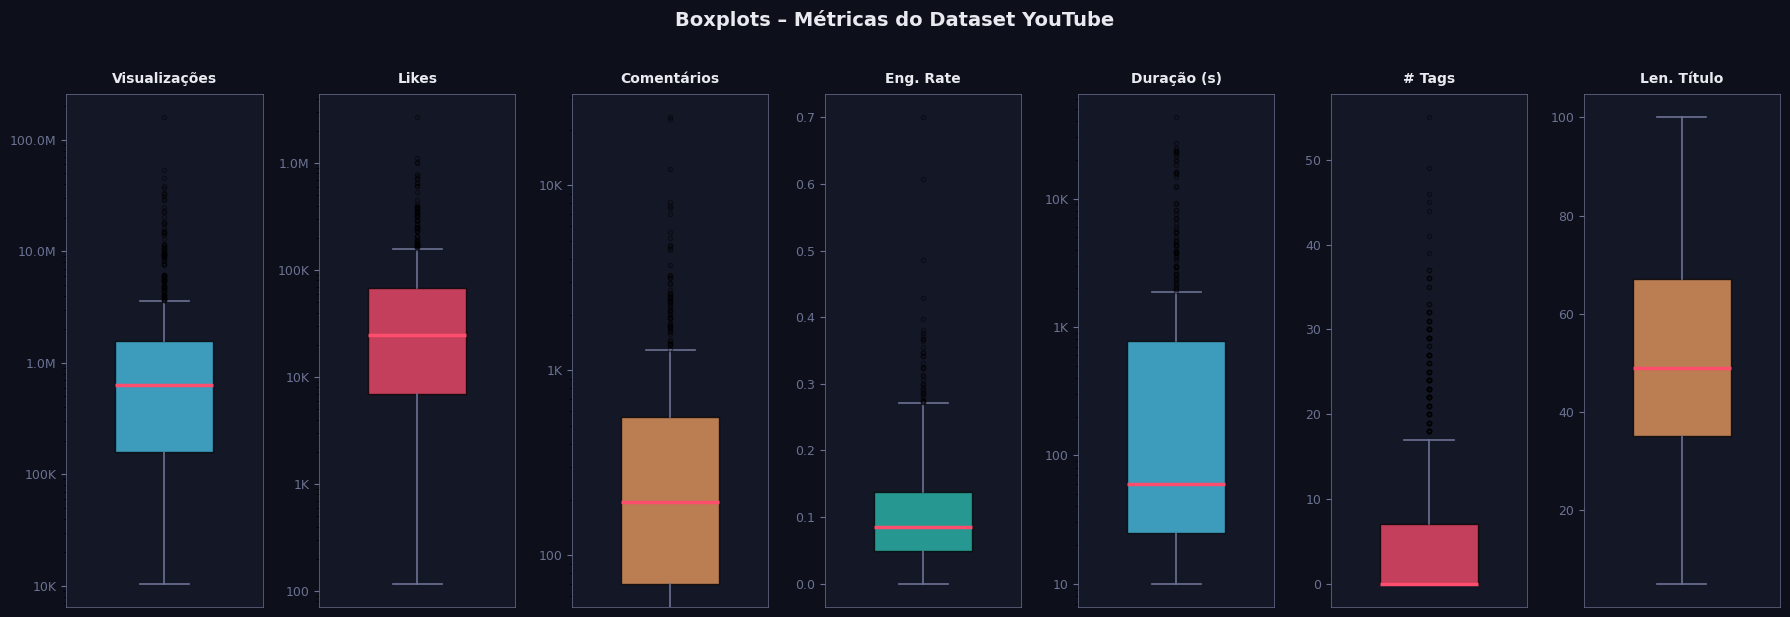

Salvo em: plots_output/2_histogramas.png


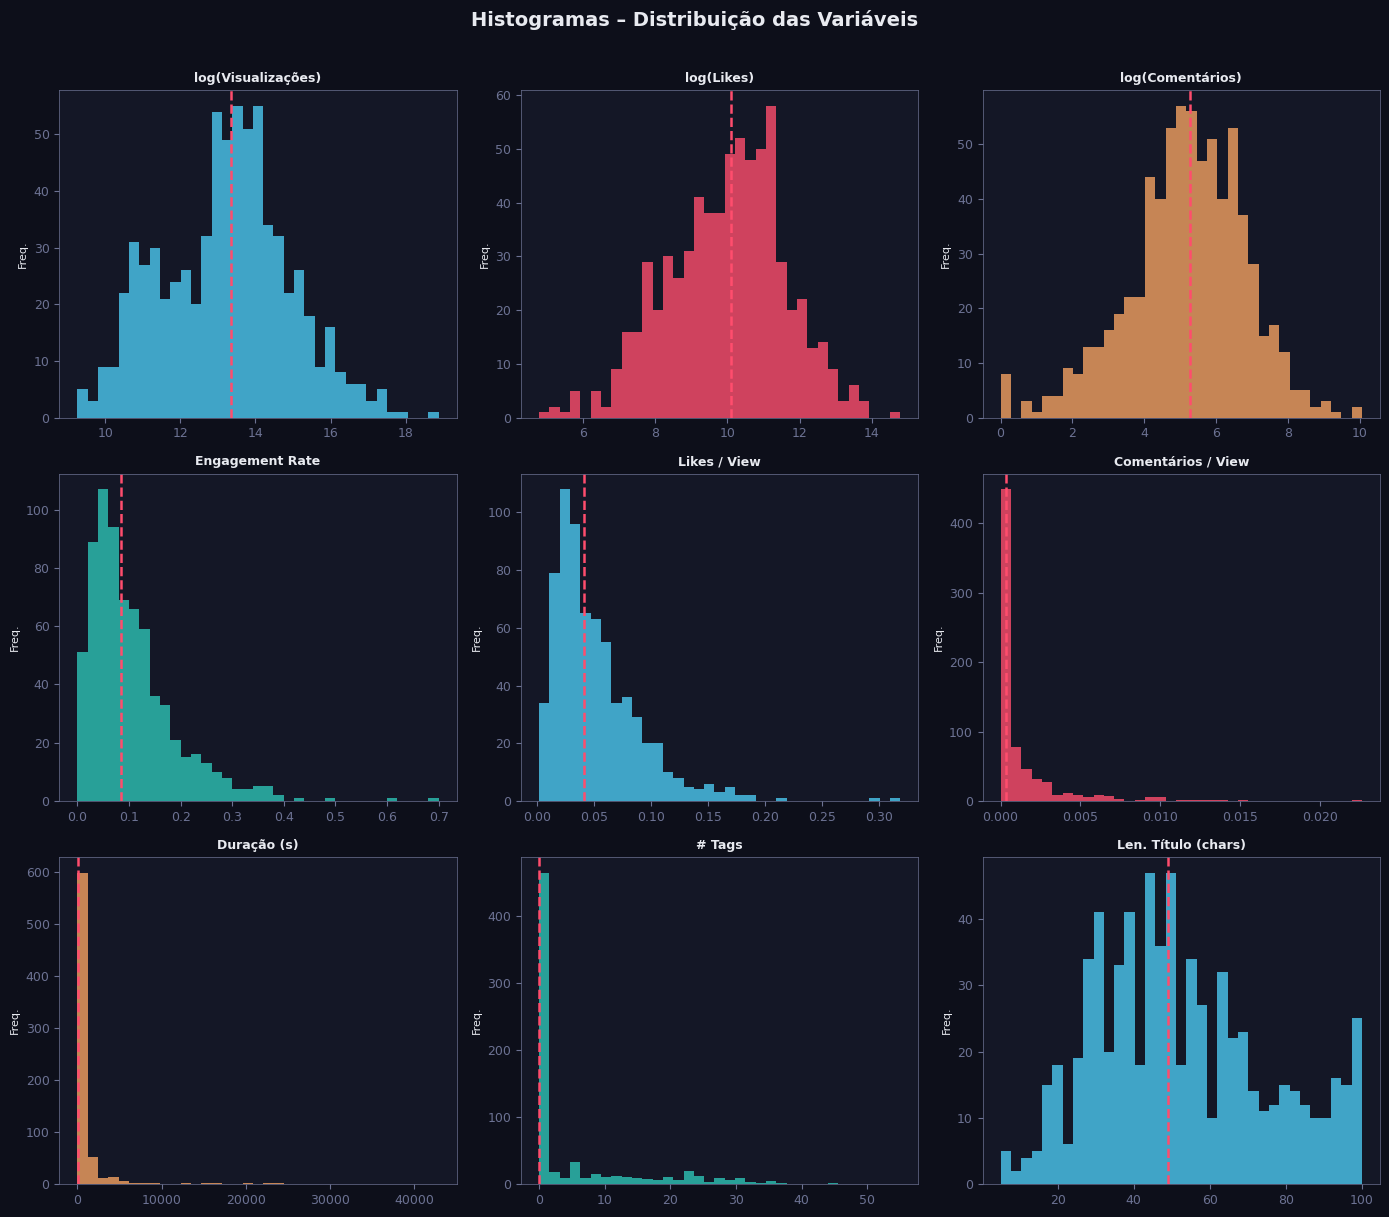

Salvo em: plots_output/3_pizza_categorias.png


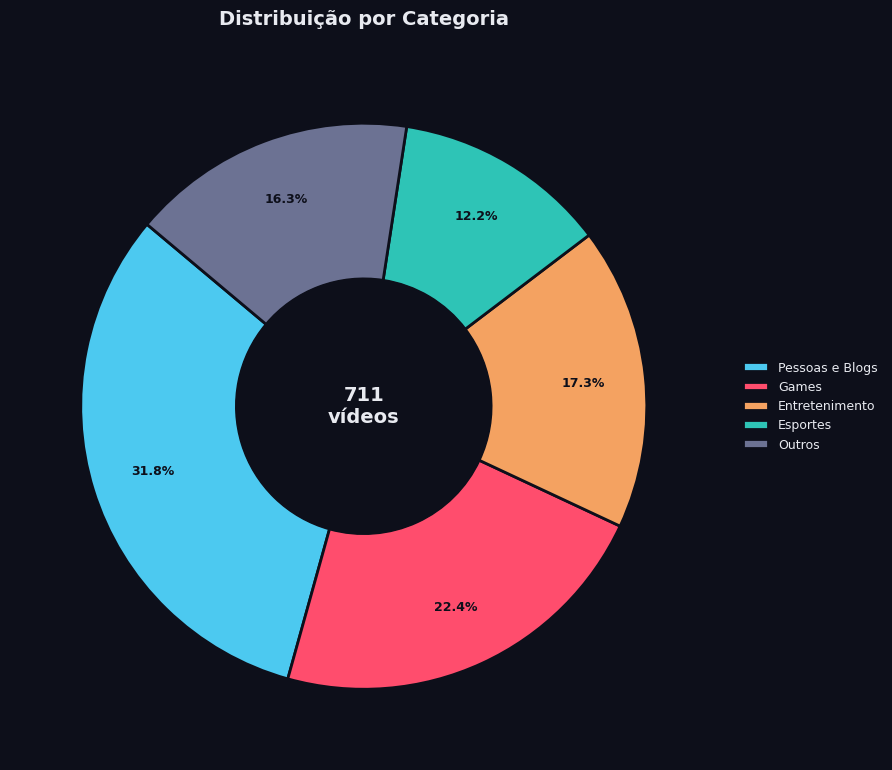

Salvo em: plots_output/4_views_por_categoria.png


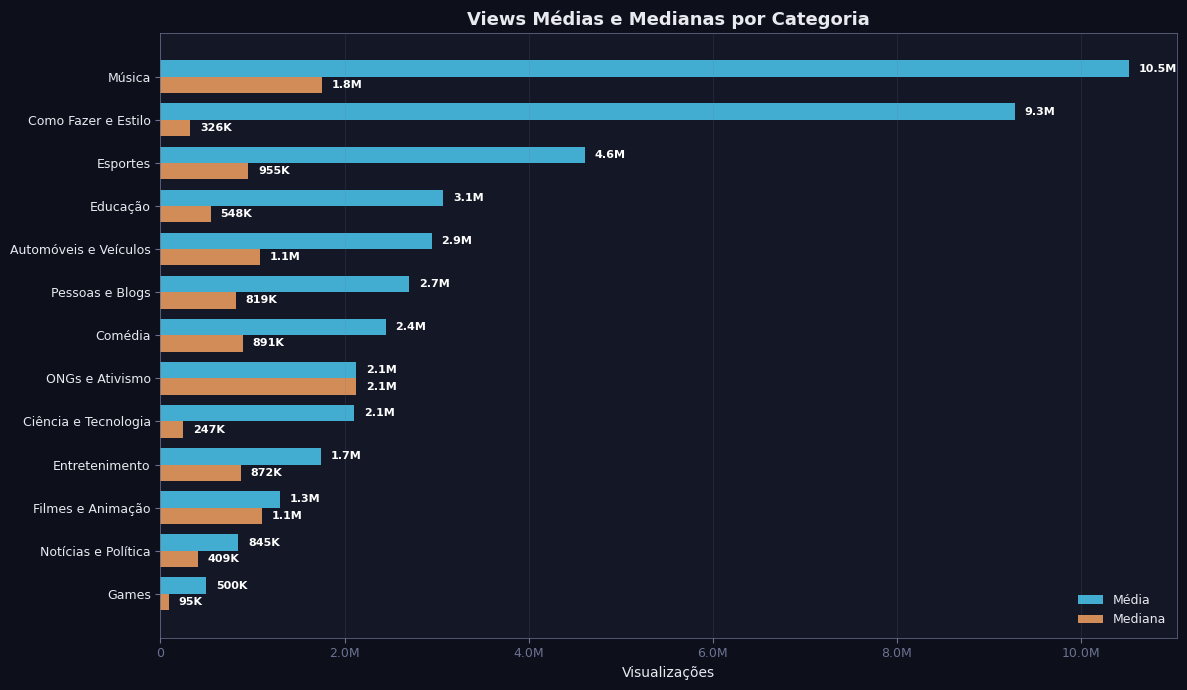

Salvo em: plots_output/5_scatter_views_likes.png


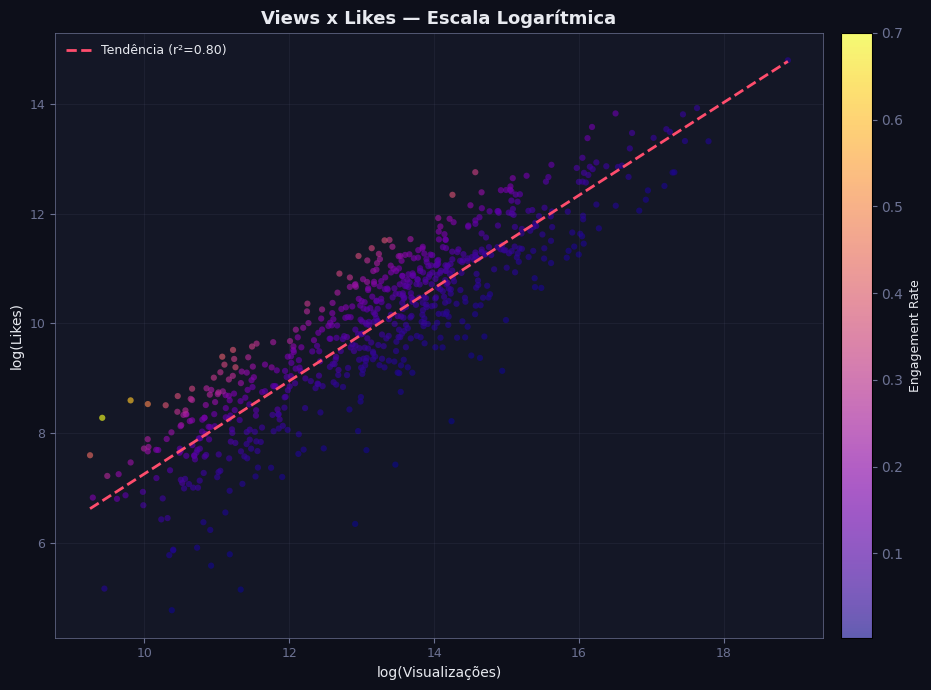

Salvo em: plots_output/6_heatmap_correlacao.png


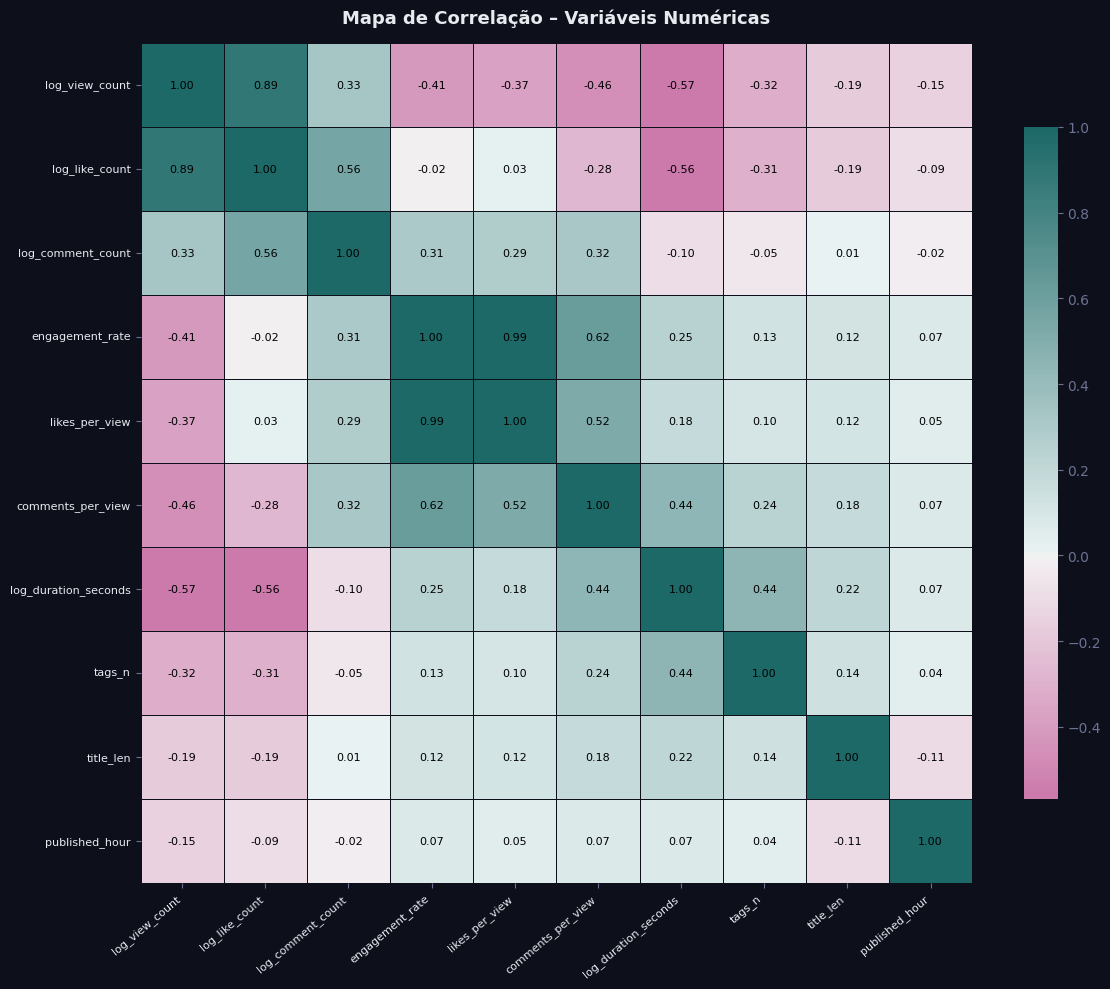

Salvo em: plots_output/7_hora_publicacao.png


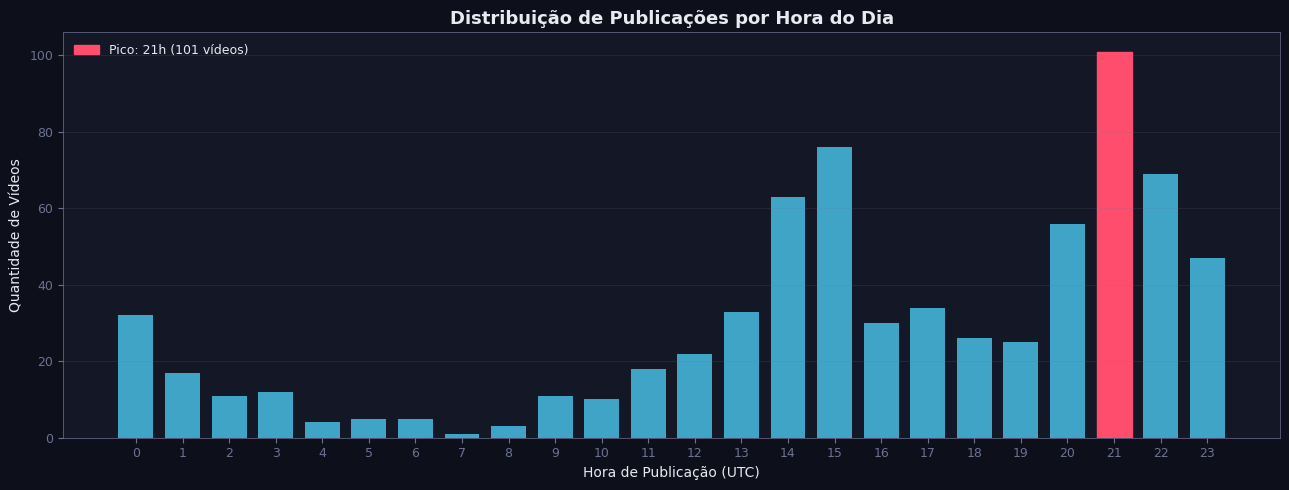

Salvo em: plots_output/8_violin_engagement.png


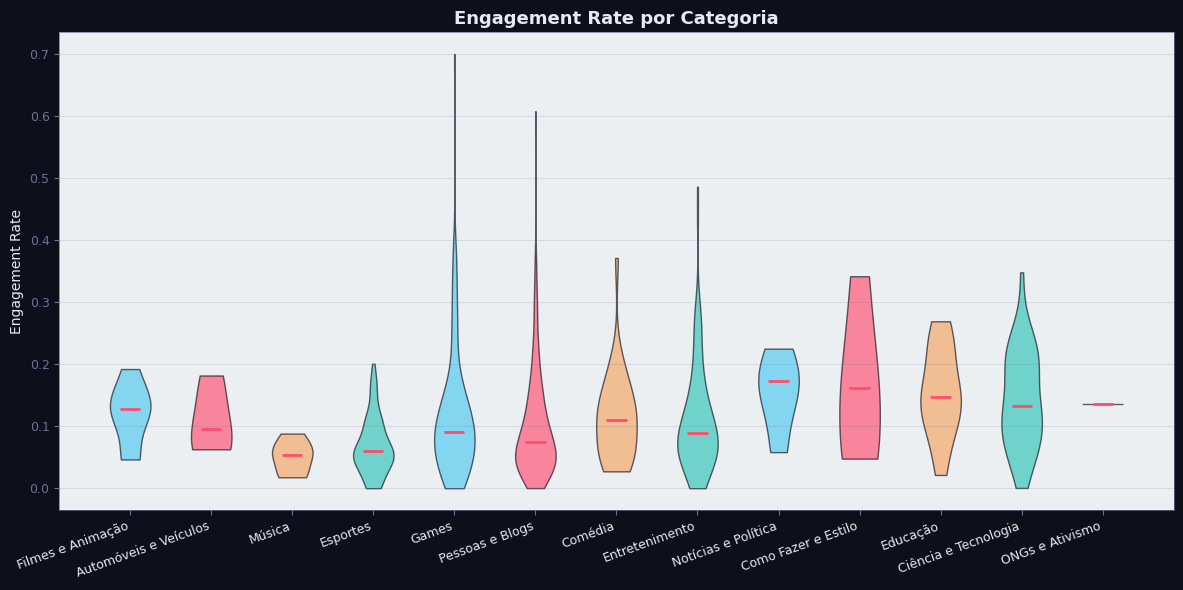

Salvo em: plots_output/9_dashboard.png


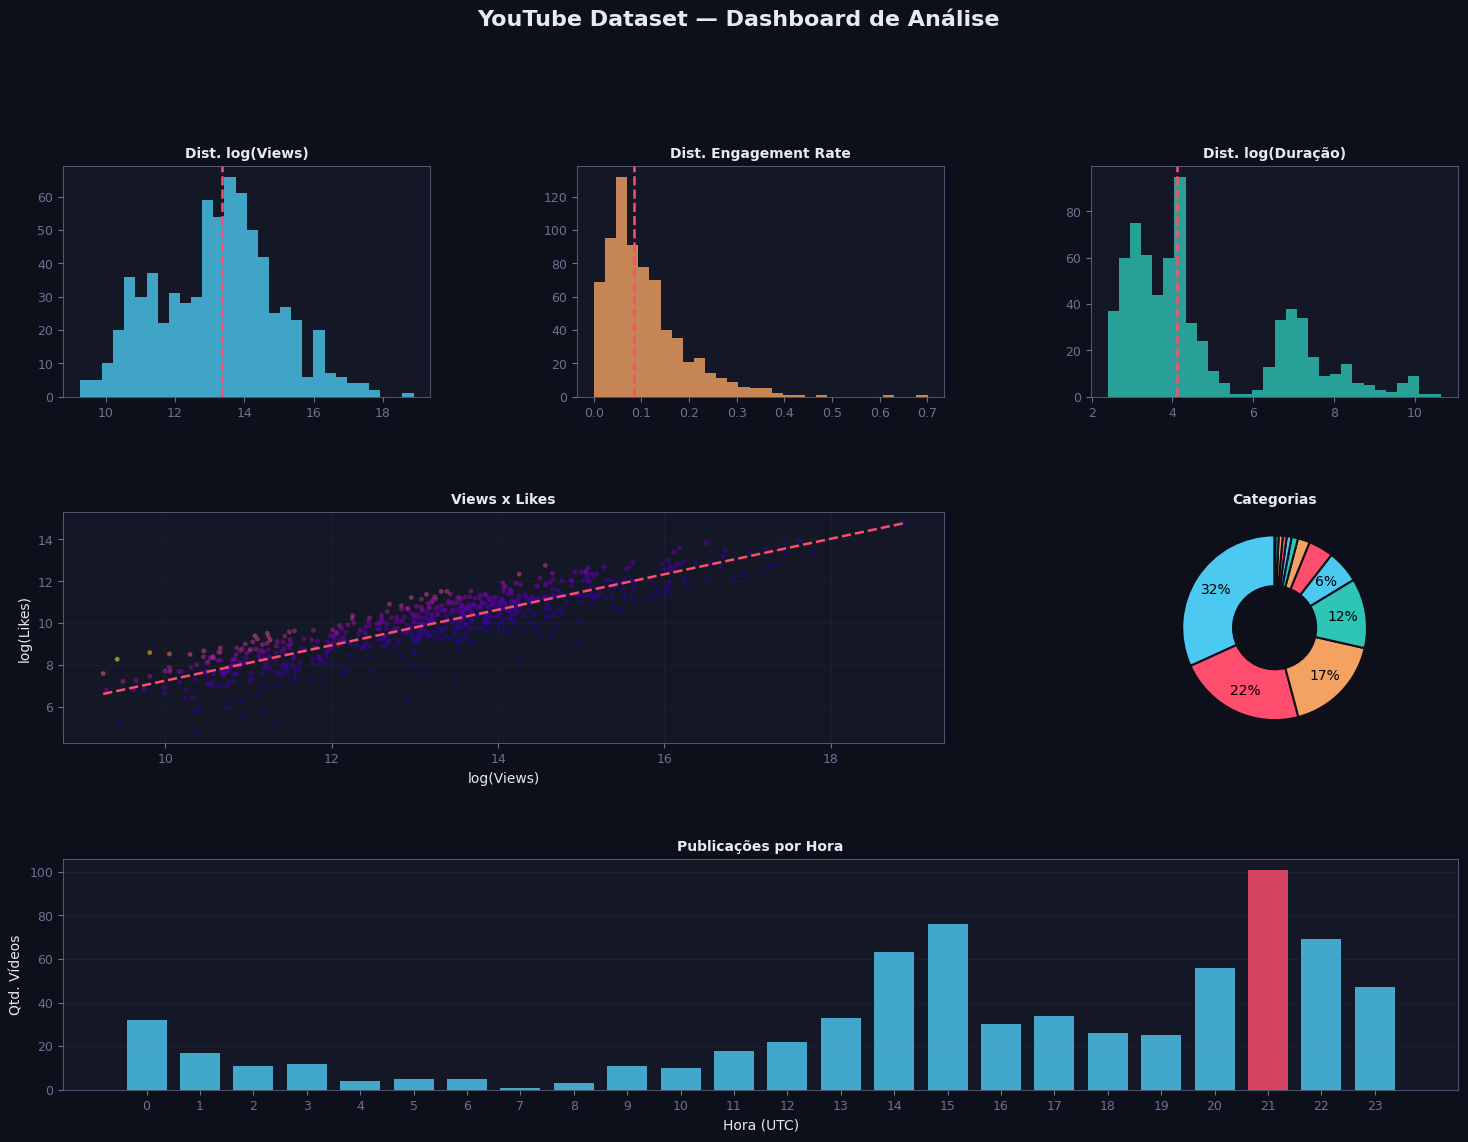

In [14]:

import src.core.plot_eda as plots_
import os
out = "plots_output"
os.makedirs(out, exist_ok=True)
plots_.plot_boxplots(df,               f"{out}/1_boxplots.png")
plots_.plot_histograms(df,             f"{out}/2_histogramas.png")
plots_.plot_category_pie(df,           f"{out}/3_pizza_categorias.png")
plots_.plot_views_by_category(df,      f"{out}/4_views_por_categoria.png")
plots_.plot_scatter_views_likes(df,    f"{out}/5_scatter_views_likes.png")
plots_.plot_correlation_heatmap(df,    f"{out}/6_heatmap_correlacao.png")
plots_.plot_publish_hour(df,           f"{out}/7_hora_publicacao.png")
plots_.plot_engagement_violin(df,      f"{out}/8_violin_engagement.png")
plots_.plot_dashboard(df,              f"{out}/9_dashboard.png")


In [37]:
df_clean = df
df_clean

,video_id,title,channel_title,channel_id,published_at,category_id,view_count,like_count,comment_count,duration,...,log_comment_count,engagement_rate,likes_per_view,comments_per_view,log_duration_seconds,published_date,published_year,published_month,published_hour,published_dayofweek
0,Au1UwwOX6JU,EU ZEREI HELLO NEIGHBOUR... MAS COM UMA DOZE!,Jazzghost,UCIXguhHCl8eDTkXpEuiGPUA,2026-06-02 15:27:08+00:00,20,256490,28386.0,2317.0,PT40M1S,...,7.748460,0.266509,0.110671,0.009033,7.784057,2026-06-02,2026,6,15,Tuesday
1,B9az2JVfDbE,Evolui Minha PICARETA no NÍVEL MÁXIMO no Minec...,ProbIems,UCrcBZDofBltcgGxphNia2tw,2026-06-02 13:00:14+00:00,20,155209,5770.0,393.0,PT16M29S,...,5.976351,0.087012,0.037176,0.002532,6.897705,2026-06-02,2026,6,13,Tuesday
2,vmqvPlJvpj4,PASSANDO A PERNA NOS MEUS AMIGOS EM UM LEILÃO!...,alanzoka,UCIwspRtKNszHhIhl36gREjQ,2026-06-02 15:00:11+00:00,20,75104,13575.0,222.0,PT1H18M40S,...,5.407172,0.376278,0.180749,0.002956,8.459776,2026-06-02,2026,6,15,Tuesday
3,j6zdTivY0mI,Henrique e Juliano 2026 Letra - As Mais Tocada...,Grow Stest,UC0Ohlg-zWxV1MdTA5IqCTMg,2026-06-01 13:58:34+00:00,10,45746,368.0,14.0,PT1H3M6S,...,2.708050,0.017619,0.008044,0.000306,8.239329,2026-06-01,2026,6,13,Monday
4,R2u139fASRw,SALLY FACE E O MISTÉRIO DA MORTADELA - Capítulo 3,Felipe Neto Joga,UCIzdh7oty8jCnXUj3eUj2WQ,2026-06-01 15:00:03+00:00,24,376423,50854.0,2630.0,PT1H31M8S,...,7.875119,0.305130,0.135098,0.006987,8.606851,2026-06-01,2026,6,15,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,tYHBE9oUO-w,3D Printed iPhone 17 Pro Mini,3DPrintastica,UCfQoBaPzz6-qtUjsAFZaSGQ,2026-05-11 17:01:13+00:00,22,3243405,23399.0,65.0,PT14S,...,4.189655,0.014529,0.007214,0.000020,2.708050,2026-05-11,2026,5,17,Monday
1125,qPuzWFvRajk,10 weird OSS projects you need right now...,Fireship,UCsBjURrPoezykLs9EqgamOA,2026-05-26 17:53:11+00:00,28,492210,21328.0,904.0,PT7M3S,...,6.807935,0.095845,0.043331,0.001837,6.049733,2026-05-26,2026,5,17,Tuesday
1126,FZE3IG2oWOc,Redmi vs Infinix charging 😳,JULIUS CONCEPTS,UCD3qZ75E-dMeF2Mhp4lHzAg,2026-05-13 08:05:14+00:00,22,4815858,50174.0,385.0,PT21S,...,5.955837,0.021237,0.010418,0.000080,3.091042,2026-05-13,2026,5,8,Wednesday
1127,cxj_SWdCbKc,Losing sleep over a phone... #tech,MDrepairs,UC4gEs2SNPr8GBNcdbQGnLjg,2026-05-17 20:19:32+00:00,28,10627712,790599.0,8091.0,PT2M59S,...,8.998631,0.152587,0.074390,0.000761,5.192957,2026-05-17,2026,5,20,Sunday


In [ ]:
import numpy as np
import pandas as pd
import ast
import isodate

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df_clf = df_clean.copy()

cats = [17, 20, 22, 23, 28]
df_clf = df_clf[df_clf["category_id"].isin(cats)].copy()

def parse_tags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).strip().lower() for t in x if str(t).strip()]
    try:
        return [t.strip().lower() for t in ast.literal_eval(x)]
    except Exception:
        x = str(x).strip()
        if x.startswith("[") and x.endswith("]"):
            x = x[1:-1]
        return [t.strip().lower().strip("'").strip('"') for t in x.split(",") if t.strip()]

def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    try:
        return int(isodate.parse_duration(x).total_seconds())
    except Exception:
        return np.nan

if "tags_list" not in df_clf.columns:
    df_clf["tags_list"] = df_clf["tags"].apply(parse_tags)

if "duration_seconds" not in df_clf.columns:
    df_clf["duration_seconds"] = df_clf["duration"].apply(duration_to_seconds)

df_clf["published_at"] = pd.to_datetime(df_clf["published_at"], utc=True, errors="coerce")
df_clf["published_year"] = df_clf["published_at"].dt.year
df_clf["published_month"] = df_clf["published_at"].dt.month
df_clf["published_dayofweek"] = df_clf["published_at"].dt.day_name()

df_clf["tags_text"] = df_clf["tags_list"].apply(lambda xs: " ".join(xs) if isinstance(xs, list) else "")
df_clf["title_text"] = df_clf["title"].fillna("")
df_clf["text_for_model"] = (df_clf["title_text"] + " " + df_clf["tags_text"]).str.strip()

df_clf["is_short"] = df_clf["duration_seconds"].le(60)

df_clf = df_clf[df_clf["text_for_model"].str.len() > 0].copy()

text_feature = "text_for_model"

numeric_features = [c for c in [
    "duration_seconds",
    "tags_n",
    "title_len",
    "title_words",
    "published_year",
    "published_month",
    "log_comment_count",
    "engagement_rate",
    "log_like_count",
    "log_view_count",
] if c in df_clf.columns]

categorical_features = [c for c in [
    "published_dayofweek",
    "is_short",
] if c in df_clf.columns]

X = df_clf[[text_feature] + numeric_features + categorical_features].copy()
y = df_clf["category_id"].copy()
groups = df_clf["channel_id"].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

for col in categorical_features:
    X_train[col] = X_train[col].astype("object")
    X_test[col] = X_test[col].astype("object")

text_transformer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=6000
)

numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_nb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("text", text_transformer, text_feature),
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

preprocessor_nb = ColumnTransformer(
    transformers=[
        ("text", text_transformer, text_feature),
        ("num", numeric_transformer_nb, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

models = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("clf", LogisticRegression(
            max_iter=5000,
            solver="saga",
            class_weight="balanced"
        ))
    ]),
    "LinearSVC": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),
    "MultinomialNB": Pipeline(steps=[
        ("preprocessor", preprocessor_nb),
        ("clf", MultinomialNB(alpha=0.5))
    ]),
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "f1_weighted": f1_score(y_test, pred, average="weighted"),
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_test, pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))

results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)
print("\nResumo dos modelos:")
print(results_df)


===== LogisticRegression =====
              precision    recall  f1-score   support

          17       0.45      0.81      0.58        16
          20       0.90      0.79      0.84        34
          22       0.74      0.48      0.58        48
          23       0.18      0.67      0.29         3
          28       0.40      0.40      0.40        10

    accuracy                           0.62       111
   macro avg       0.53      0.63      0.54       111
weighted avg       0.70      0.62      0.64       111

Confusion matrix:
[[13  0  2  1  0]
 [ 0 27  3  1  3]
 [14  1 23  7  3]
 [ 0  0  1  2  0]
 [ 2  2  2  0  4]]

===== LinearSVC =====
              precision    recall  f1-score   support

          17       0.55      0.75      0.63        16
          20       0.88      0.82      0.85        34
          22       0.70      0.62      0.66        48
          23       0.00      0.00      0.00         3
          28       0.57      0.40      0.47        10

    accuracy         

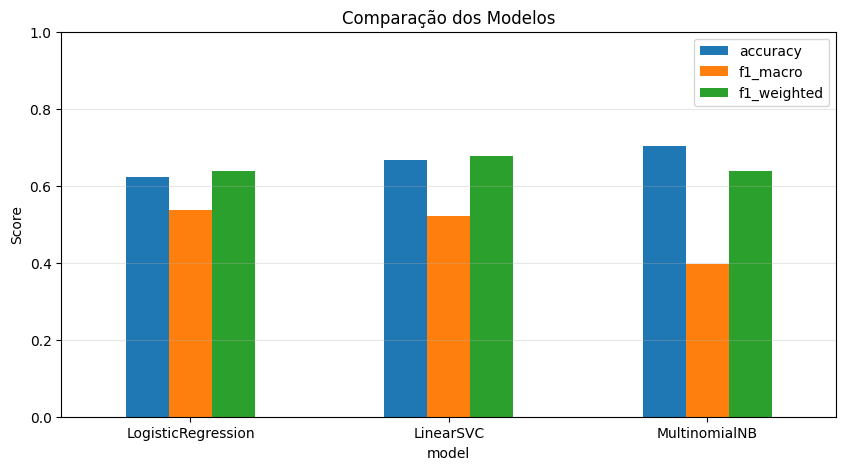

In [64]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("model")

plot_df[["accuracy", "f1_macro", "f1_weighted"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparação dos Modelos")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

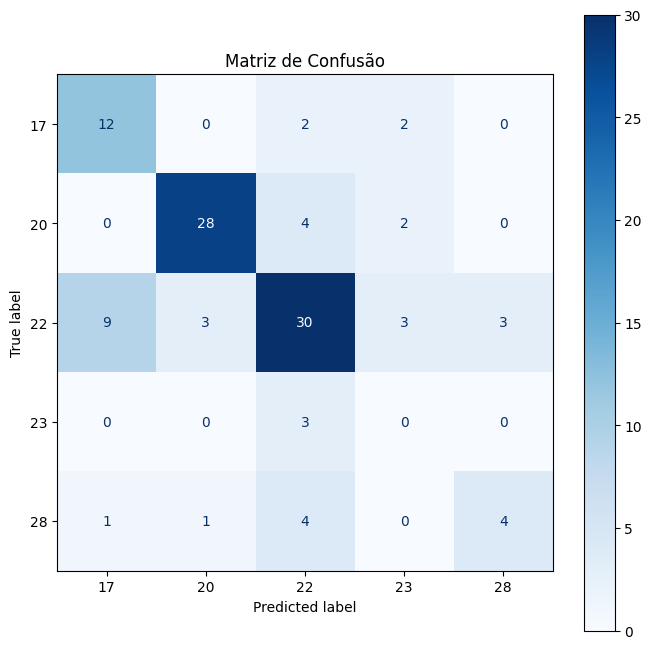

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models["LinearSVC"]
pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    ax=ax,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.show()

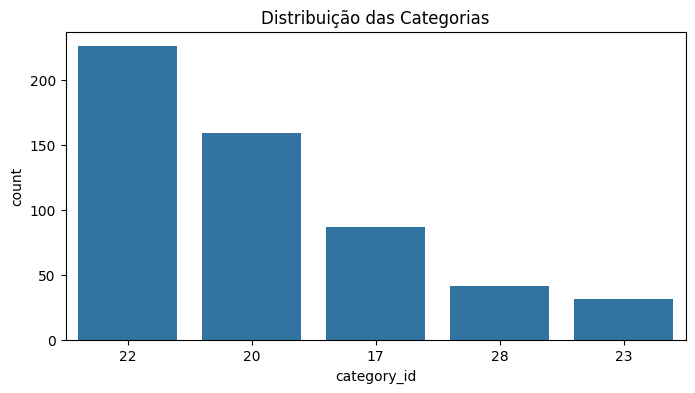

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_clf,
    x="category_id",
    order=df_clf["category_id"].value_counts().index
)

plt.title("Distribuição das Categorias")
plt.show()

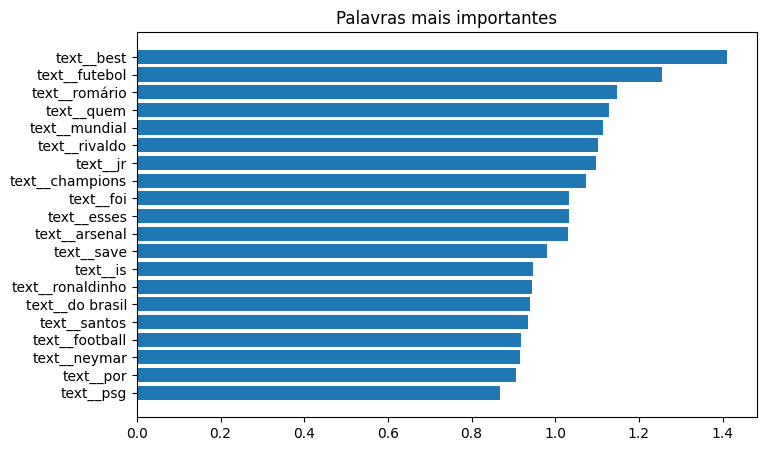

In [ ]:
svc = models["LinearSVC"]

# 1. Get feature names
feature_names = (
    svc.named_steps["preprocessor"]
       .get_feature_names_out()
)

coef = svc.named_steps["clf"].coef_
cat_idx = 0

top = coef[cat_idx].argsort()[-20:]

plt.figure(figsize=(8,5))
plt.barh(
    np.array(feature_names)[top],
    coef[cat_idx][top]
)
plt.title("Palavras mais importantes")
plt.show()

In [ ]:
import re
import emoji

def clean_title(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def extract_title_features(title):

    title = str(title)

    words = title.split()

    return {
        "title_len": len(title),
        "word_count": len(words),

        "uppercase_ratio":
            sum(c.isupper() for c in title) /
            max(len(title), 1),

        "digit_count":
            sum(c.isdigit() for c in title),

        "exclamation_count":
            title.count("!"),

        "question_count":
            title.count("?"),

        "ellipsis_count":
            title.count("..."),

        "emoji_count":
            len([c for c in title if c in emoji.EMOJI_DATA]),

        "has_hashtag":
            int("#" in title),

        "has_number":
            int(any(c.isdigit() for c in title)),

        "has_caps_word":
            int(any(
                len(w) > 2 and w.isupper()
                for w in words
            ))
    }
df["title"] = df["title"].apply(clean_title)

feature_df = pd.DataFrame(
    df["title"].apply(extract_title_features).tolist()
)

from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=3
)

X_word = word_tfidf.fit_transform(df["title"])

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=2000
)

X_char = char_tfidf.fit_transform(df["title"])

from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X_numeric = csr_matrix(feature_df.values)

X = hstack([
    X_numeric,
    X_word,
    X_char
])

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=20,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

for c in sorted(df["cluster"].unique()):

    print(f"\n=== CLUSTER {c} ===")

    sample = df[df["cluster"] == c]["title"].head(10)

    for t in sample:
        print(t)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 43545 stored elements and shape (711, 2432)>

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    df["title"].tolist(),
    show_progress_bar=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8676.55it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 23/23 [00:04<00:00,  5.16it/s]


array([[ 0.09927929,  0.15584971,  0.11022184, ...,  0.11155661,
        -0.40517014,  0.13849351],
       [-0.06757042,  0.12530936,  0.12546797, ..., -0.1266955 ,
        -0.12980768, -0.28899544],
       [-0.01977941,  0.30845177,  0.04066723, ...,  0.02143371,
        -0.02907343, -0.01865835],
       ...,
       [-0.14436804,  0.5010987 , -0.3205327 , ..., -0.22896415,
         0.04243463,  0.13781478],
       [-0.12611283,  0.24386711,  0.23867689, ..., -0.2037937 ,
        -0.12351853,  0.02266959],
       [-0.20467348,  0.27576125,  0.2580342 , ..., -0.10418905,
        -0.14563912,  0.19269928]], shape=(711, 384), dtype=float32)